<a href="https://colab.research.google.com/github/CallmeSharanya/BCI_Transfer_Learning/blob/main/mspca_filterbank_preprocess%2Bmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne pywavelets

import mne
import numpy as np
import pywt

In [ ]:
def load_physionet(subjects=[1,2,3], runs=[6,10,14]):
    raws = []

    for s in subjects:
        for r in runs:
            try:
                files = mne.datasets.eegbci.load_data(s, r)
                raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
                raws.append(raw)
            except:
                continue

    raw = mne.concatenate_raws(raws)

    print(raw)
    return raw

In [ ]:
def mspca_denoise(X, wavelet='db4', level=4):
    X_out = []

    for trial in X:
        trial_out = []
        for ch in trial:
            coeffs = pywt.wavedec(ch, wavelet, level=level)

            coeffs_thresh = []
            for c in coeffs:
                thr = np.median(np.abs(c)) / 0.6745
                c = pywt.threshold(c, thr, mode='soft')
                coeffs_thresh.append(c)

            rec = pywt.waverec(coeffs_thresh, wavelet)
            trial_out.append(rec[:len(ch)])

        X_out.append(trial_out)

    return np.array(X_out)

In [ ]:
def preprocess_physionet_mspca_filterbank(raw):
    # -------- Basic preprocessing --------
    raw.resample(160)
    raw.set_eeg_reference('average', projection=False)

    # -------- Extract events --------
    events, event_id = mne.events_from_annotations(raw)

    # Keep only motor imagery: T1 (left), T2 (right)
    valid_ids = {k: v for k, v in event_id.items() if k in ['T1', 'T2']}

    if len(valid_ids) == 0:
        raise ValueError("No T1/T2 events found!")

    epochs = mne.Epochs(
        raw,
        events,
        event_id=valid_ids,
        tmin=0.5,
        tmax=3.5,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()   # (trials, channels, time)
    y = epochs.events[:, -1]

    # Convert labels → 0,1
    unique = np.unique(y)
    label_map = {v: i for i, v in enumerate(unique)}
    y = np.array([label_map[i] for i in y])

    print("Before MSPCA:", X.shape)

    # -------- MSPCA --------
    X = mspca_denoise(X)

    # -------- Filter Bank --------
    bands = [(8,12), (12,16), (16,20), (20,30)]
    X_fb = []

    for low, high in bands:
        band_data = []

        for trial in X:
            trial_band = []
            for ch in trial:
                filtered = mne.filter.filter_data(
                    ch,
                    sfreq=160,
                    l_freq=low,
                    h_freq=high,
                    verbose=False
                )
                trial_band.append(filtered)

            band_data.append(trial_band)

        X_fb.append(np.array(band_data))

    # Stack bands → channels dimension
    X = np.concatenate(X_fb, axis=1)

    print("After Filter Bank:", X.shape)

    # -------- Normalization --------
    mean = X.mean(axis=-1, keepdims=True)
    std = X.std(axis=-1, keepdims=True)
    X = (X - mean) / (std + 1e-6)

    return X, y

In [ ]:
raw = load_physionet(subjects=[1,2,3])

X, y = preprocess_physionet_mspca_filterbank(raw)

print("Final shape:", X.shape)
print("Labels:", np.unique(y))

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m20s (2.5 MB)


Download complete in 17s (2.5 MB)


Download complete in 18s (2.5 MB)


Download complete in 17s (2.4 MB)


Download complete in 18s (2.4 MB)


Download complete in 19s (2.4 MB)


Download complete in 19s (2.5 MB)


Download complete in 18s (2.5 MB)


Download complete in 18s (2.5 MB)
<RawEDF | S001R06.edf, 64 x 179040 (1119.0 s), ~87.5 MiB, data loaded>
Sampling frequency of the instance is already 160.0, returning unmodified.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Before MSPCA: (135, 64, 481)
After Filter Bank: (135, 256, 481)
Final shape: (135, 256, 481)
Labels: [0 1]


In [ ]:
def mspca_denoise(X, wavelet='db4', level=4):
    X_out = []

    for trial in X:
        trial_out = []
        for ch in trial:
            coeffs = pywt.wavedec(ch, wavelet, level=level)

            coeffs_thresh = []
            for c in coeffs:
                thr = np.median(np.abs(c)) / 0.6745
                c = pywt.threshold(c, thr, mode='soft')
                coeffs_thresh.append(c)

            rec = pywt.waverec(coeffs_thresh, wavelet)
            trial_out.append(rec[:len(ch)])

        X_out.append(trial_out)

    return np.array(X_out)

In [ ]:
def preprocess_physionet_mspca_filterbank(raw):
    # -------- Basic preprocessing --------
    raw.resample(160)
    raw.set_eeg_reference('average', projection=False)

    # -------- Extract events --------
    events, event_id = mne.events_from_annotations(raw)

    # Keep only motor imagery: T1 (left), T2 (right)
    valid_ids = {k: v for k, v in event_id.items() if k in ['T1', 'T2']}

    if len(valid_ids) == 0:
        raise ValueError("No T1/T2 events found!")

    epochs = mne.Epochs(
        raw,
        events,
        event_id=valid_ids,
        tmin=0.5,
        tmax=3.5,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()   # (trials, channels, time)
    y = epochs.events[:, -1]

    # Convert labels → 0,1
    unique = np.unique(y)
    label_map = {v: i for i, v in enumerate(unique)}
    y = np.array([label_map[i] for i in y])

    print("Before MSPCA:", X.shape)

    # -------- MSPCA --------
    X = mspca_denoise(X)

    # -------- Filter Bank --------
    bands = [(8,12), (12,16), (16,20), (20,30)]
    X_fb = []

    for low, high in bands:
        band_data = []

        for trial in X:
            trial_band = []
            for ch in trial:
                filtered = mne.filter.filter_data(
                    ch,
                    sfreq=160,
                    l_freq=low,
                    h_freq=high,
                    verbose=False
                )
                trial_band.append(filtered)

            band_data.append(trial_band)

        X_fb.append(np.array(band_data))

    # Stack bands → channels dimension
    X = np.concatenate(X_fb, axis=1)

    print("After Filter Bank:", X.shape)

    # -------- Normalization --------
    mean = X.mean(axis=-1, keepdims=True)
    std = X.std(axis=-1, keepdims=True)
    X = (X - mean) / (std + 1e-6)

    return X, y

In [ ]:
raw = load_physionet(subjects=[1,2,3])

X, y = preprocess_physionet_mspca_filterbank(raw)

print("Final shape:", X.shape)
print("Labels:", np.unique(y))

<RawEDF | S001R06.edf, 64 x 179040 (1119.0 s), ~87.5 MiB, data loaded>
Sampling frequency of the instance is already 160.0, returning unmodified.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Before MSPCA: (135, 64, 481)
After Filter Bank: (135, 256, 481)
Final shape: (135, 256, 481)
Labels: [0 1]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EEGNet_LSTM(nn.Module):
    def __init__(self, chans, samples, num_classes=2):
        super().__init__()

        # -------- EEGNet Block --------
        self.firstconv = nn.Sequential(
            nn.Conv2d(1, 16, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16)
        )

        self.depthwiseConv = nn.Sequential(
            nn.Conv2d(16, 32, (chans, 1), groups=16, bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(0.5)
        )

        self.separableConv = nn.Sequential(
            nn.Conv2d(32, 32, (1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(32),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(0.25)
        )

        # -------- LSTM --------
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # -------- Classifier --------
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (B, C, T)

        x = x.unsqueeze(1)  # (B, 1, C, T)

        x = self.firstconv(x)
        x = self.depthwiseConv(x)
        x = self.separableConv(x)

        # reshape for LSTM
        x = x.squeeze(2)        # (B, F, T')
        x = x.permute(0, 2, 1)  # (B, T', F)

        x, _ = self.lstm(x)

        x = x[:, -1, :]  # last timestep
        x = self.fc(x)

        return x

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

def prepare_dataloaders(X, y, batch_size=32):
    # Step 1: Train vs temp (70 / 30)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=42
    )

    # Step 2: Val vs Test (15 / 15)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        stratify=y_temp,
        random_state=42
    )

    # Convert to tensors
    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )

    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.long)
    )

    test_ds = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    )

    # Loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

    return train_loader, val_loader, test_loader

In [ ]:
import torch
import torch.nn as nn

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-4,
    patience=15,
    grad_clip=1.0
):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay  # ✅ L2 regularization
    )

    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    best_model = None
    counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()

            # ✅ Gradient clipping (important for LSTM)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            total_loss += loss.item()

        # 🔍 Validation
        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Val Acc={val_acc:.4f}")

        # ✅ Early stopping logic
        if val_acc > best_acc:
            best_acc = val_acc
            best_model = model.state_dict()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    # 🔁 Restore best model
    if best_model is not None:
        model.load_state_dict(best_model)

    print(f"Best Validation Accuracy: {best_acc:.4f}")

    return model

In [ ]:
def evaluate(model, loader):
    device = next(model.parameters()).device
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

In [ ]:
# Assume you already ran preprocessing:
# X, y = preprocess_raw(raw)

y = y - y.min()  # normalize labels to 0,1

train_loader, val_loader, test_loader = prepare_dataloaders(X, y)

model = EEGNet_LSTM(
    chans=X.shape[1],
    samples=X.shape[2],
    num_classes=len(set(y))
)

model = train_model(model, train_loader, test_loader, epochs=1000)

Train: 94, Val: 20, Test: 21
Epoch 1: Loss=2.0912, Val Acc=0.4762
Epoch 2: Loss=2.0753, Val Acc=0.4762
Epoch 3: Loss=2.0567, Val Acc=0.4762
Epoch 4: Loss=2.0255, Val Acc=0.5238
Epoch 5: Loss=2.0068, Val Acc=0.4286
Epoch 6: Loss=1.9802, Val Acc=0.4286
Epoch 7: Loss=1.9369, Val Acc=0.4286
Epoch 8: Loss=1.8346, Val Acc=0.4762
Epoch 9: Loss=1.7838, Val Acc=0.5238
Epoch 10: Loss=1.6632, Val Acc=0.5238
Epoch 11: Loss=1.4537, Val Acc=0.5238
Epoch 12: Loss=1.4689, Val Acc=0.5238
Epoch 13: Loss=1.2926, Val Acc=0.5238
Epoch 14: Loss=0.9857, Val Acc=0.5238
Epoch 15: Loss=1.0539, Val Acc=0.5238
Epoch 16: Loss=0.9650, Val Acc=0.5238
Epoch 17: Loss=0.7795, Val Acc=0.5714
Epoch 18: Loss=0.4805, Val Acc=0.5714
Epoch 19: Loss=0.6583, Val Acc=0.6190
Epoch 20: Loss=0.6195, Val Acc=0.6190
Epoch 21: Loss=0.5934, Val Acc=0.6190
Epoch 22: Loss=0.6367, Val Acc=0.6190
Epoch 23: Loss=0.5160, Val Acc=0.6190
Epoch 24: Loss=0.4751, Val Acc=0.6667
Epoch 25: Loss=0.3900, Val Acc=0.6190
Epoch 26: Loss=0.4736, Val Acc

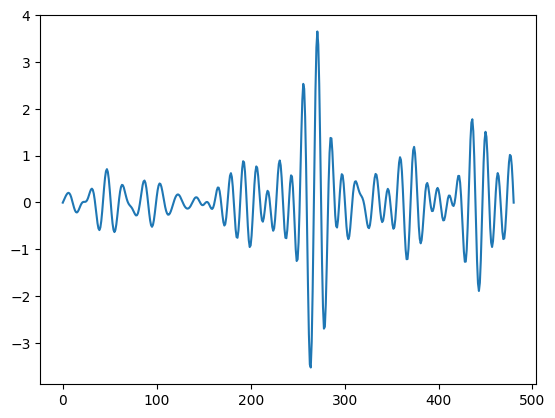

In [ ]:
import matplotlib.pyplot as plt
plt.plot(X[0][0])